In [8]:
# Cell 1 — Load
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import pyreadstat

# Start from the encoded analysis table, then bring in ANC visits from the raw KR file.
df = pd.read_csv("../data/processed/tamilnadu_nfhs5_encoded.csv")
kr_anc = pyreadstat.read_dta("../data/raw/IAKR7EFL.DTA", usecols=["caseid", "m14"])[0]
kr_anc = kr_anc.rename(columns={"m14": "anc_visits"})
df = df.merge(kr_anc, on="caseid", how="left")

if "stunting_haz" in df.columns and "stunting_label" not in df.columns:
    df["stunting_label"] = (df["stunting_haz"] < -2.0).astype(int)

print(df.shape, df["stunting_label"].value_counts())

(8247, 51) stunting_label
0    6096
1    2151
Name: count, dtype: int64


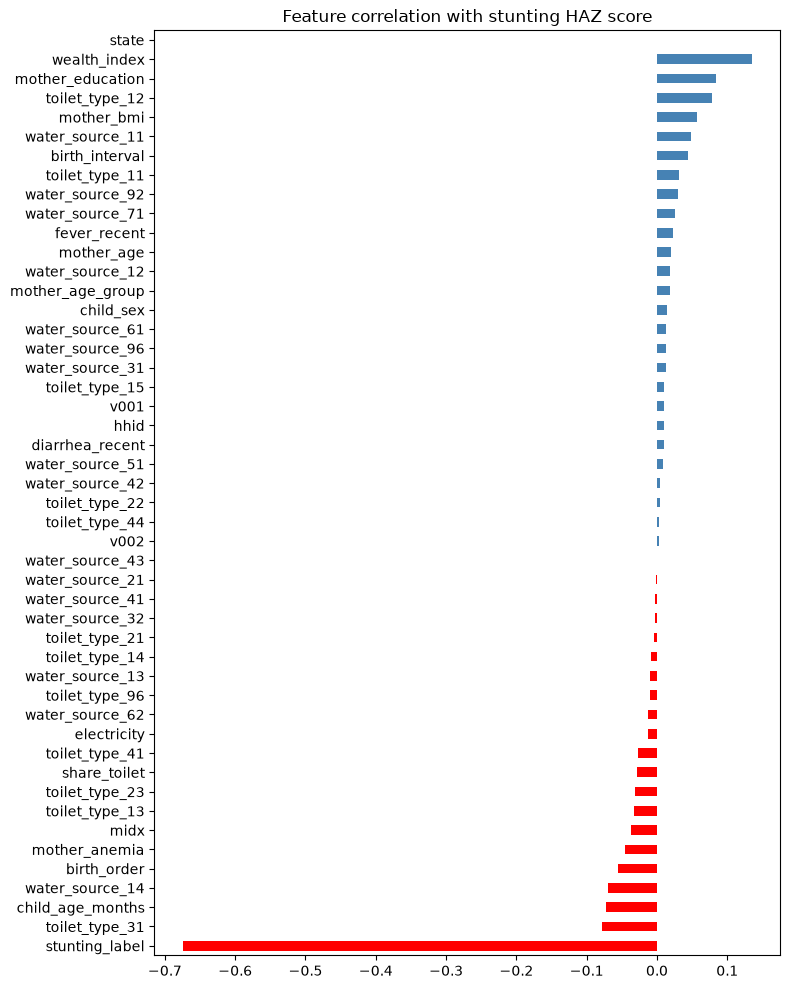

In [2]:
# Cell 2 — Correlation heatmap (numeric vs stunting_haz)
numeric_cols = df.select_dtypes(include="number").columns.tolist()
corr = df[numeric_cols].corr()["stunting_haz"].drop("stunting_haz").sort_values()
plt.figure(figsize=(8,10))
corr.plot(kind="barh", color=["red" if x < 0 else "steelblue" for x in corr])
plt.title("Feature correlation with stunting HAZ score")
plt.tight_layout()
plt.savefig("../outputs/figures/corr_haz.png", dpi=150)

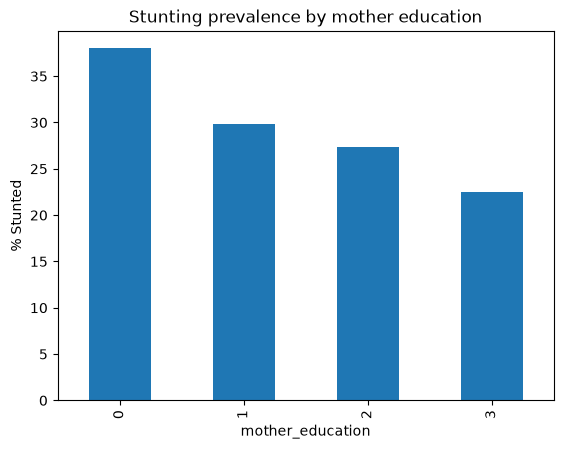

In [3]:
# Cell 3 — Stunting prevalence by education level
prev_edu = df.groupby("mother_education")["stunting_label"].mean() * 100
prev_edu.plot(kind="bar", title="Stunting prevalence by mother education")
plt.ylabel("% Stunted"); plt.savefig("../outputs/figures/prev_by_education.png", dpi=150)

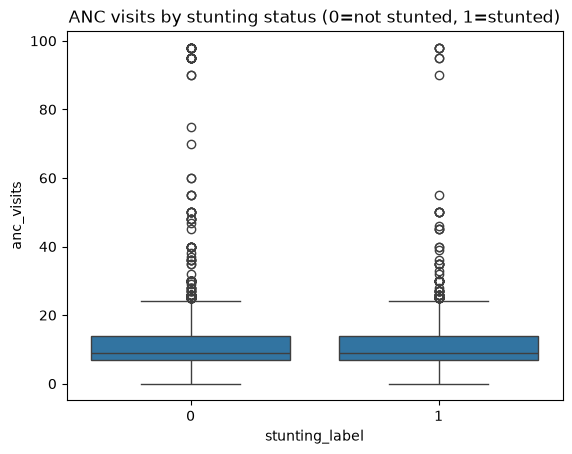

In [9]:
# Cell 4 — Boxplot: ANC visits by stunting status (novel vs Erda)
sns.boxplot(x="stunting_label", y="anc_visits", data=df)
plt.title("ANC visits by stunting status (0=not stunted, 1=stunted)")
plt.savefig("../outputs/figures/anc_by_stunting.png", dpi=150)